In [1]:
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from itertools import accumulate


In [2]:
sio.whosmat("ECG_TP4.mat")
mat_struct = sio.loadmat("ECG_TP4.mat")

ecg_lead = mat_struct["ecg_lead"].flatten()
qrs_detections = mat_struct["qrs_detections"].flatten()




In [4]:
# Parameters
hb_length = 600
hb_start = -250
hb_end = 350
half_length = int(hb_length // 2)
fs = 1000

heartbeats = [ecg_lead[int(q + hb_start): int(q + hb_end)] for q in qrs_detections]
heartbeats_dt = [sig.detrend(h) for h in heartbeats]
heartbeats_dt = heartbeats_dt / np.max(np.abs(heartbeats_dt), axis=1, keepdims=True)

Gráfico de todos los latidos detectados en superposición


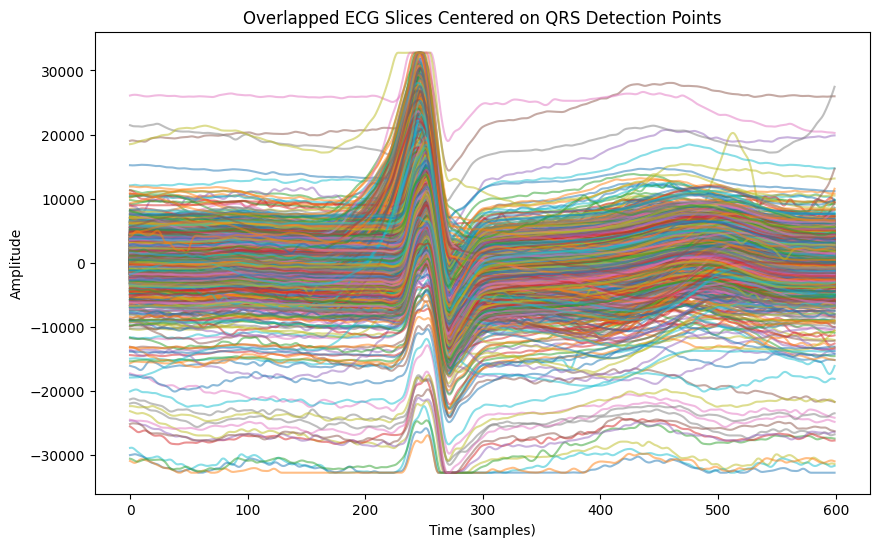

In [5]:
plt.figure(figsize=(10, 6))

for slice_segment in heartbeats:
    plt.plot(slice_segment, alpha=0.5)  
plt.title("Overlapped ECG Slices Centered on QRS Detection Points")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

Latidos superpuestos luego de aplicar un detrend para eliminar la linea de base y normalizar su amplitud

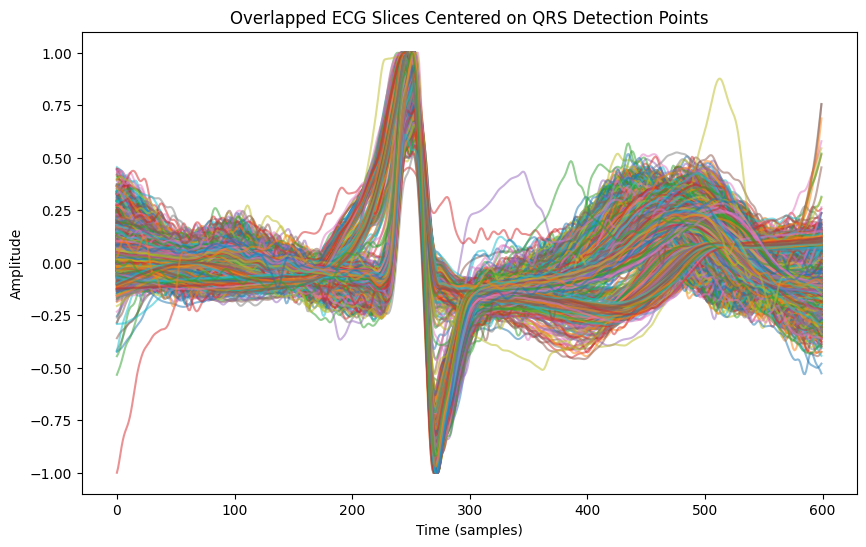

In [6]:
plt.figure(figsize=(10, 6))

for slice_segment in heartbeats_dt:
    plt.plot(slice_segment, alpha=0.5) 
plt.title("Overlapped ECG Slices Centered on QRS Detection Points")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

Amplitud promedio de latido

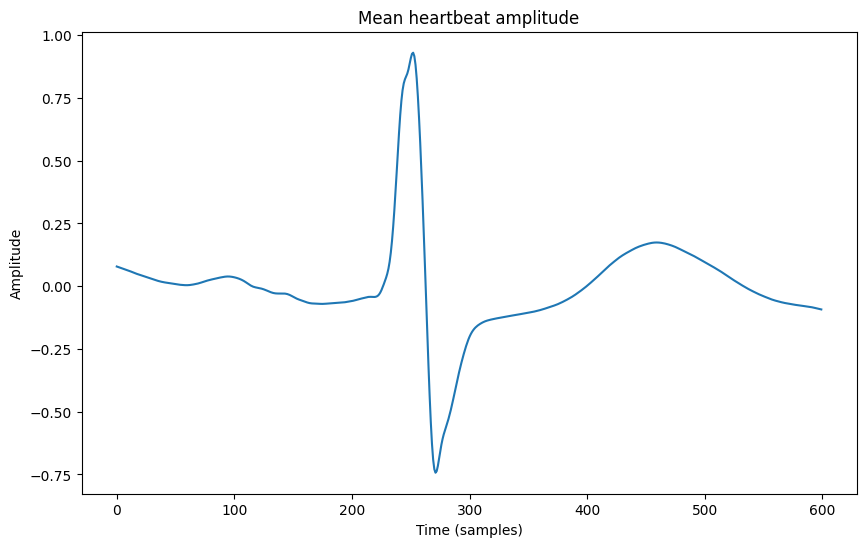

In [7]:
plt.figure(figsize=(10, 6))

mean_hb = np.mean(heartbeats_dt, axis=0)
plt.plot(mean_hb)
plt.title("Mean heartbeat amplitude")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()


Ahora vamos a calcular y gráficar la PSD de cada latido por separado y luego ver el promedio de las mismas, el cual será nuestro estimador final de la PSD de la ECG

/var/folders/rf/3frjb3md42s8fp_lvn8fwj7c0000gn/T/ipykernel_80845/322127341.py:23: RuntimeWarning: divide by zero encountered in log10
  plt.plot(f_mean, 10 * np.log10(Pxx_matrix[i, half_length:]), color='red')
/var/folders/rf/3frjb3md42s8fp_lvn8fwj7c0000gn/T/ipykernel_80845/322127341.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot( f_mean, 10 * np.log10(Pxx_mean[half_length:]), "--r", linewidth=3, label="AVG PSD", color="green"


<Figure size 1200x600 with 0 Axes>

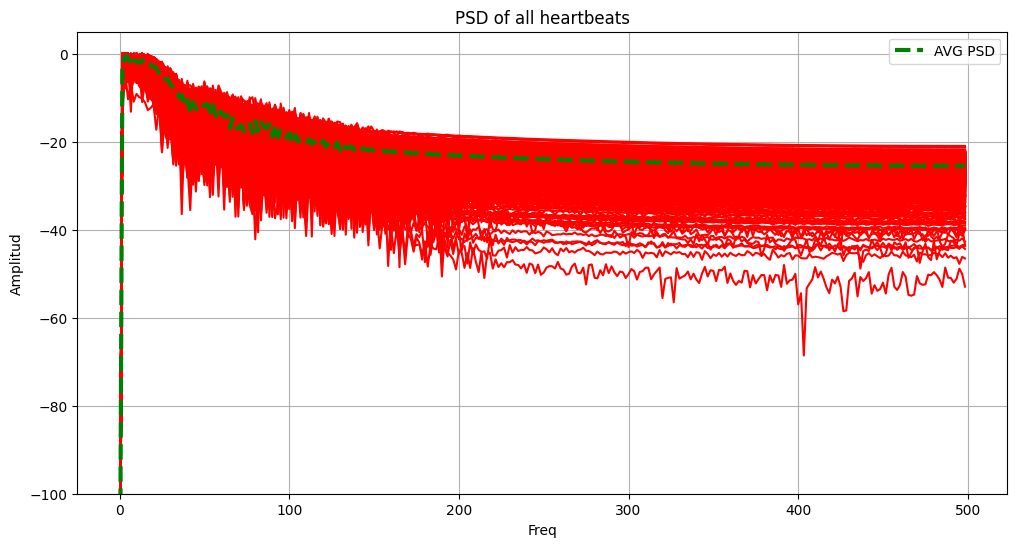

In [8]:
N = heartbeats_dt.shape[1]
plt.figure(figsize=(12, 6))


hb_spectrum = np.fft.fft(heartbeats_dt)
Pxx_matrix = (np.abs(hb_spectrum) / hb_length)

for i in range(Pxx_matrix.shape[0]):
    Pxx_matrix[i, :] /= np.max(Pxx_matrix[i, :])
    Pxx_matrix[i, :] = np.fft.fftshift(Pxx_matrix[i, :])

Pxx_mean = np.mean(Pxx_matrix, axis=0)
f_mean = np.fft.fftfreq(600, d=1 / fs)
f_mean = np.fft.fftshift(f_mean)
f_mean = f_mean[half_length:]

plt.figure(figsize=(12,6))
plt.title("PSD of all heartbeats")
plt.xlabel("Freq")
plt.ylabel(f"Amplitud")  ## Revisar LaTex
plt.ylim([-100, 5])
for i in range(heartbeats_dt.shape[0]):
    plt.plot(f_mean, 10 * np.log10(Pxx_matrix[i, half_length:]), color='red')
plt.plot( f_mean, 10 * np.log10(Pxx_mean[half_length:]), "--r", linewidth=3, label="AVG PSD", color="green"
)
plt.grid()
plt.legend()
plt.show()

# Estimación del ancho de banda

Vamos a observar el espectro de la señal completa y analizar que queremos filtrar


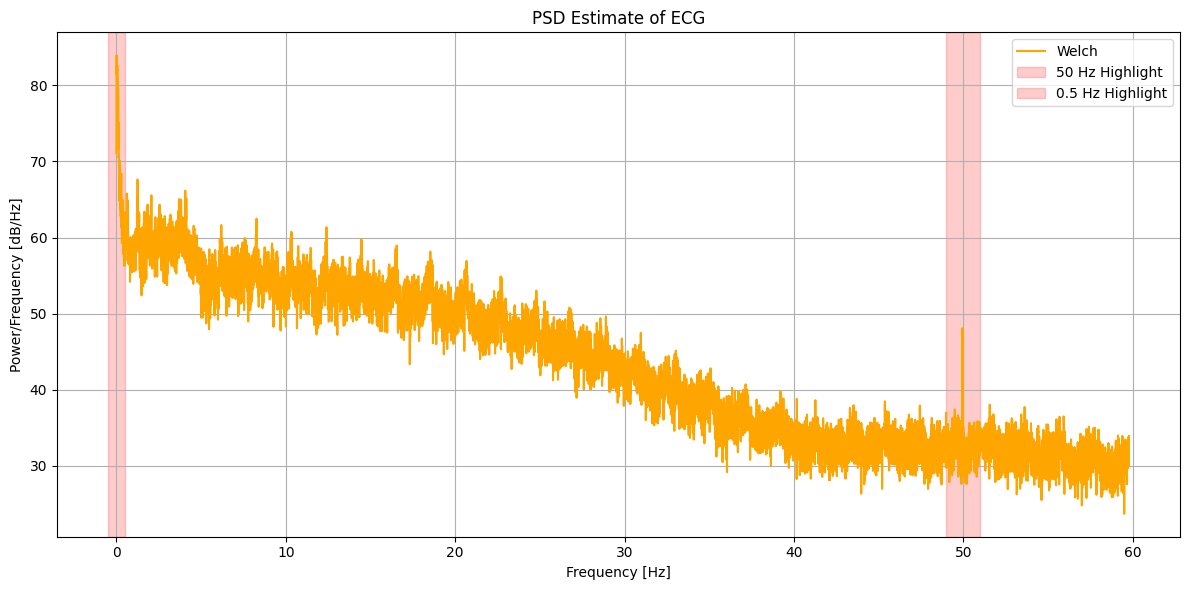

In [44]:
f, p = sig.welch(ecg_lead, fs=1000, nperseg=len(ecg_lead)/5)

hz_60 = (len(f) // 500) * 60
hz_51 = (len(f) // 500) * 51
hz_49 = (len(f) // 500) * 49


plt.figure(figsize=(12, 6))

plt.plot(f[:hz_60],  10*np.log10(p[:hz_60]), label="Welch", color="orange")

plt.title("PSD Estimate of ECG")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency [dB/Hz]")
plt.axvspan(49, 51, color='red', alpha=0.2, label="50 Hz Highlight")  # Shaded region
plt.axvspan(-0.5, 0.5, color='red', alpha=0.2, label="0.5 Hz Highlight")  # Shaded region


plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

En este gráfico podemos ver remarcadas interferencias que eremos eliminar tanto cerca de continua como en 50hz, por lo cual, bajo la hipotesis de que nuestra señal se encuentra comprendida en estos rangos de frecuencia, vamos a estimar una plantilla pasabanda.

# Análisis de la Cota Superior del Ancho de Banda de una Señal ECG

Al analizar cada latido por separado, utilizamos ventanas de tamaño N = 600, lo que reduce la resolución espectral a:

`Δf = fs / N = 1.66 Hz`

Por esta razón solo podemos analizar que sucede a frecuencias que superen los 1.66 Hz. Debido a esto utilizaremos este estimador para encontrar la cota superior del BW de la señal ECG


# Estimación de la cota superior del BW de la señal ECG

Para conocer el BW de la señal vamos a integrar su PSD de forma tal que logremos conocer hasta que frecuencia se encuentra contenido cierto % de la energía total de la señal.
En este caso utilicé el siguiente criterio

BW = 80%

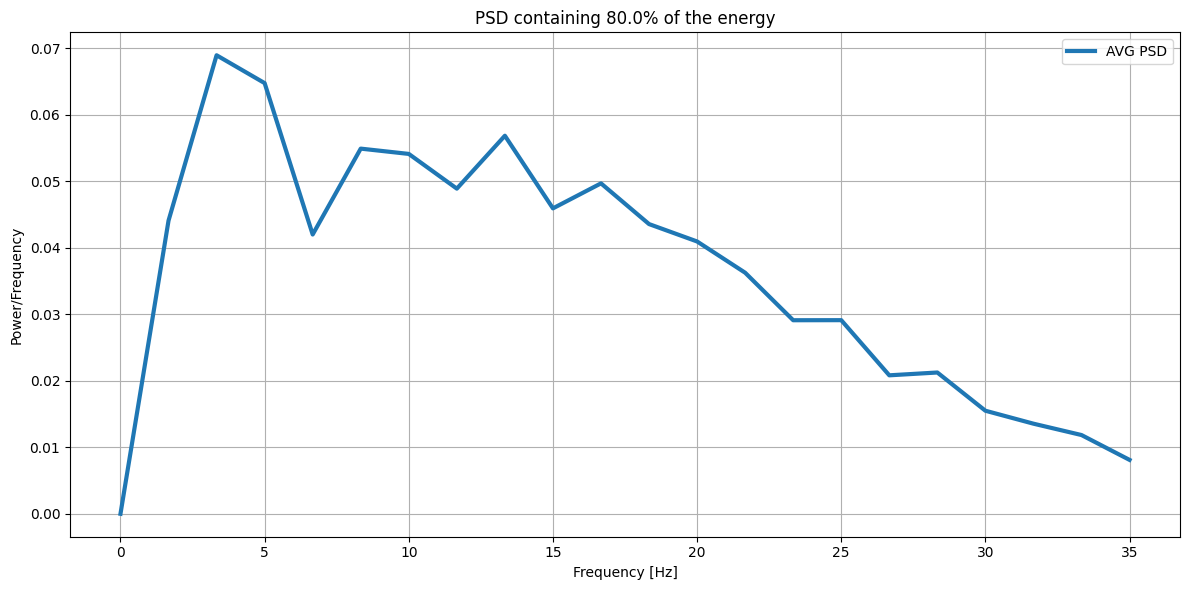

In [9]:
Pxx_mean_normalized = Pxx_mean[half_length:] / Pxx_mean[half_length:].sum()

p_bw = 0.8
p_cumulative = np.array(list(accumulate(Pxx_mean_normalized)))
p_index = np.argmax(p_cumulative >= p_bw)


plt.figure(figsize=(12, 6))

plt.plot( f_mean[:p_index], Pxx_mean_normalized[:p_index], linewidth=3, label="AVG PSD")

plt.title(f"PSD containing {p_bw*100}% of the energy")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency")


plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Considerando el 80% del area bajo la curva de la PSD normalizada obtenemos un la cota superior del BW = 35Hz

# Estimación de la cota inferior

Como podemos observar en la PSD promedio, no hay energía en las frecuencias cercanas a 0hz, esto sucede por el inconveniente para analizar estas frecuencias debido a la resolución espectral antes mencionado.

Para realizar el analísis de baja frecuencia realizaremos una estimación de la PSD de toda la señal por medio del método de welch utilizando 5 ventanas, obteniendo un largo de ventana

`nperseg = N / 5 = 225823`

y una resolución espectral de

`Δf = fs / (N / 5) ~= 0.004 Hz`

Pudiendo así observar con claridad lo sucedido entre 0 y 1Hz


In [40]:
len(ecg_lead) // 5

225823

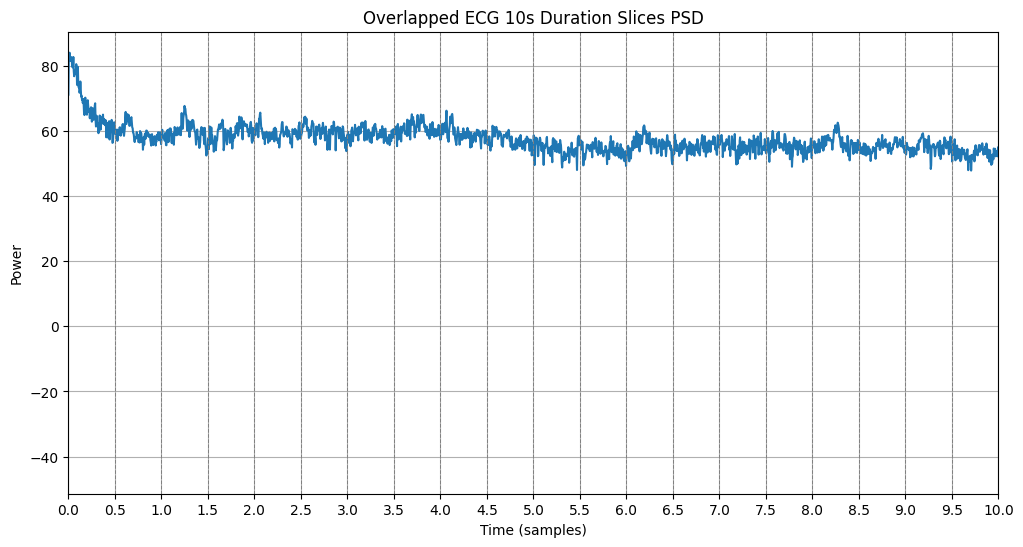

In [ ]:

plt.figure(figsize=(12, 6))

plt.plot(f, 10 * np.log10(p))
plt.title("Overlapped ECG 10s Duration Slices PSD")
plt.xlabel("Time (samples)")
plt.ylabel("Power")
plt.xlim(0, 10)

plt.xticks(np.arange(0, 10.5, 0.5))

for x in np.arange(0.5, 10.5, 0.5):
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.7)

plt.grid()  
plt.show()



Podemos observar en el gráfico que el ruido en baja se encuentra por debajo de los 0.5hz por lo cual utilizaremos esta cota inferior quedando nuestra plantilla final
#       freq   - att
# ws1 = 0.1 Hz - 40db
# wp1 = 0.5 Hz - 0.5db
# wp2 = 30 Hz  - 0.5db 
# ws2 = 45 Hz  - 40db